In [1]:
import pandas as pd

In [2]:
phf19_data = pd.read_csv('/users/s/h/shuhang/PHF19/phf19_data_30mar2026.csv')

In [3]:
phf19_data.sort_values('ic50', ascending=True)['smiles'].tolist()

['Cn1nc(Br)c2c(N3CCC[C@@H](NC4CCC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC[C@H](NC4CC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCCC(NC4CCC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC[C@H](NC4CCC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCCC(NC4CC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(I)c2c(N3CCCN(CC4CC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCCC(NC4CCC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCCN(CC4CC4)CC3)nc(N3CC(F)(F)C(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC(NC4CC4)CC3)nc(N3CCC(F)(F)C3)nc21',
 'CC1CCN(c2nc(N3CCC(F)(F)C3)nc3c2c(Br)nn3C)CC1NC1CCC1',
 'C#Cc1nn(C)c2nc(N3CCC(F)(F)C3)nc(N3CCCN(CC4CC4)CC3)c12',
 'Cn1nc(Br)c2c(N3CCC[C@H](NC4CCC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC4(CC4)[C@H](NC4CC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC[C@@H](NC4CC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC[C@@H](NC4CC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC4(CC4)C(NC4CC4)C3)nc(N3CCC(F)(F)C3)nc21',
 'Cn1nc(Br)c2c(N3CCC(NCC4CC4)CC3)nc(N3CCC(F

In [4]:
from rdkit import Chem

sdf_path = "6WAU-SAR-30mar2026/top01_frame0007_pocket000_ligands_ranked.sdf"
# Reads all molecules into a list
sdf_supplier = Chem.SDMolSupplier(sdf_path)
mols = [mol for mol in sdf_supplier if mol is not None]

[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[15:13:40] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

In [5]:
len(mols)

262

In [6]:
mols[0].GetPropsAsDict()

{'SMILES': 'Cn1nc(Br)c2c(N3CCCC(NC4CCC4)C(C)(C)C3)nc(N3CCC(F)(F)C3)nc21',
 'minimizedAffinity': -8.28219,
 'CNNscore': 0.9562903047,
 'CNNaffinity': 8.0142393112,
 'CNN_VS': 7.663939476,
 'CNNaffinity_variance': 0.3482426703}

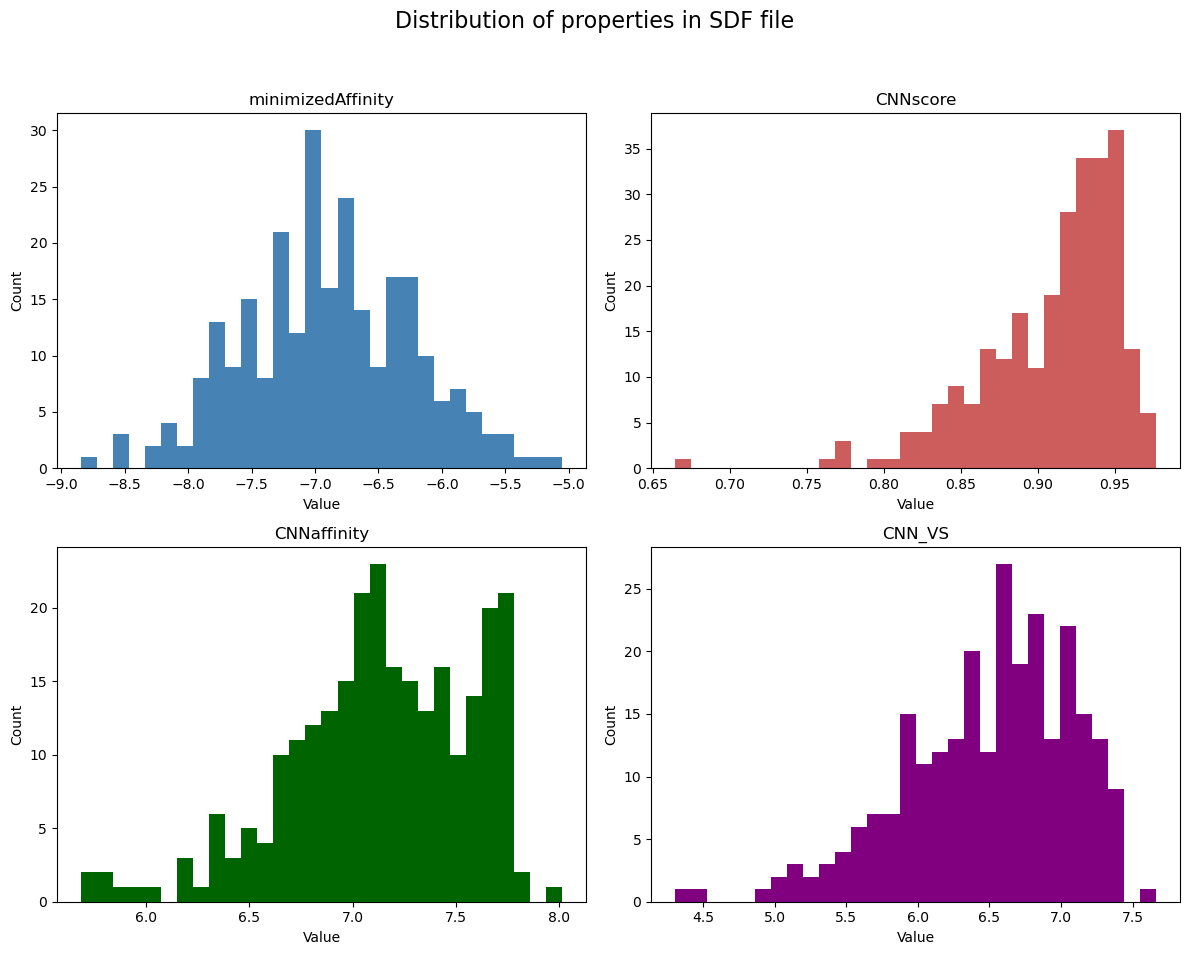

In [7]:
import matplotlib.pyplot as plt

# Extract desired properties from the molecules
affinities = []
cnn_scores = []
cnn_affinities = []
cnn_vs = []

for mol in mols:
    props = mol.GetPropsAsDict()
    # Sometimes RDKit returns numpy.float32 so cast to float for safety
    affinities.append(float(props.get('minimizedAffinity', float('nan'))))
    cnn_scores.append(float(props.get('CNNscore', float('nan'))))
    cnn_affinities.append(float(props.get('CNNaffinity', float('nan'))))
    cnn_vs.append(float(props.get('CNN_VS', float('nan'))))

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of properties in SDF file', fontsize=16)

axs[0, 0].hist(affinities, bins=30, color='steelblue')
axs[0, 0].set_title('minimizedAffinity')

axs[0, 1].hist(cnn_scores, bins=30, color='indianred')
axs[0, 1].set_title('CNNscore')

axs[1, 0].hist(cnn_affinities, bins=30, color='darkgreen')
axs[1, 0].set_title('CNNaffinity')

axs[1, 1].hist(cnn_vs, bins=30, color='purple')
axs[1, 1].set_title('CNN_VS')

for ax in axs.flat:
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

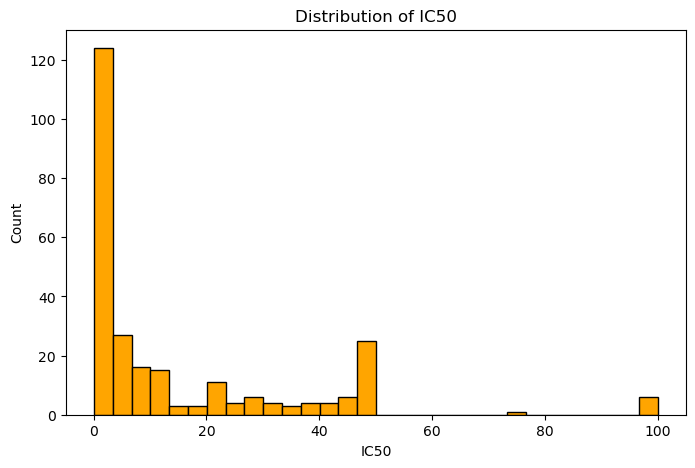

In [8]:
import matplotlib.pyplot as plt

# Assume 'df' is the DataFrame that has the 'ic50' column.
plt.figure(figsize=(8, 5))
plt.hist(phf19_data['ic50'].dropna(), bins=30, color='orange', edgecolor='black')
plt.xlabel('IC50')
plt.ylabel('Count')
plt.title('Distribution of IC50')
plt.show()

In [9]:
# Merge sdf properties to phf19_data using compound name

import numpy as np
import pandas as pd

# Extract properties from mols into a DataFrame, indexed by '_Name'
molprops = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props['_Name'] = mol.GetProp('_Name') if mol.HasProp('_Name') else None
    molprops.append(props)
mol_df = pd.DataFrame(molprops)

# Merge into phf19_data using 'name' from phf19_data and '_Name' from mol_df
combined_df = pd.merge(
    phf19_data, 
    mol_df, 
    how='inner', 
    left_on='name', 
    right_on='_Name'
)

# Compute pIC50 from ic50 column (in micromolar)
ic50_um = combined_df['ic50'].replace(0, np.nan)
combined_df['pIC50'] = 6 - np.log10(ic50_um)

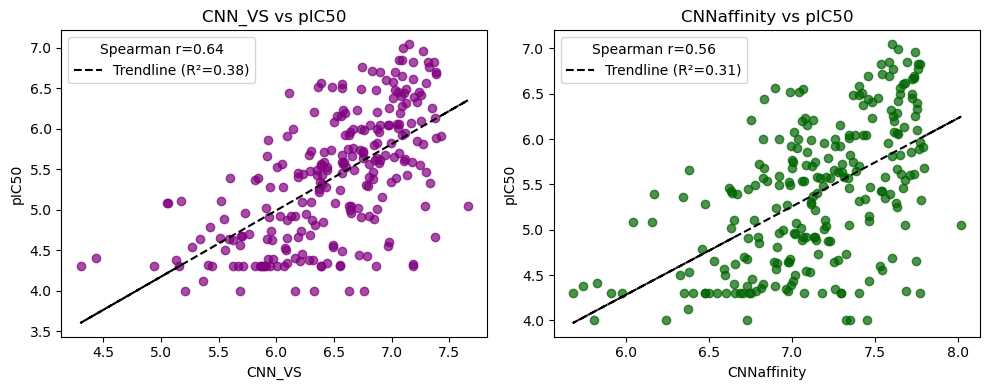

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress, spearmanr

plt.figure(figsize=(10, 4))

# Plot for CNN_VS vs pIC50
plt.subplot(1, 2, 1)
x1 = combined_df['CNN_VS'].values
y1 = combined_df['pIC50'].values
plt.scatter(x1, y1, color='purple', alpha=0.7)

# Linear regression
mask1 = ~np.isnan(x1) & ~np.isnan(y1)
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1[mask1], y1[mask1])
trendline1 = slope1 * x1 + intercept1
plt.plot(x1, trendline1, color='black', linestyle='--', label=f'Trendline (R²={r_value1**2:.2f})')
# Spearman correlation
spearman_r1, spearman_p1 = spearmanr(x1[mask1], y1[mask1])
plt.xlabel('CNN_VS')
plt.ylabel('pIC50')
plt.title('CNN_VS vs pIC50')
plt.legend(title=f"Spearman r={spearman_r1:.2f}")

# Plot for CNNaffinity vs pIC50
plt.subplot(1, 2, 2)
x2 = combined_df['CNNaffinity'].values
y2 = combined_df['pIC50'].values
plt.scatter(x2, y2, color='darkgreen', alpha=0.7)

# Linear regression
mask2 = ~np.isnan(x2) & ~np.isnan(y2)
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2[mask2], y2[mask2])
trendline2 = slope2 * x2 + intercept2
plt.plot(x2, trendline2, color='black', linestyle='--', label=f'Trendline (R²={r_value2**2:.2f})')
# Spearman correlation
spearman_r2, spearman_p2 = spearmanr(x2[mask2], y2[mask2])
plt.xlabel('CNNaffinity')
plt.ylabel('pIC50')
plt.title('CNNaffinity vs pIC50')
plt.legend(title=f"Spearman r={spearman_r2:.2f}")

plt.tight_layout()
plt.show()

In [11]:
combined_df.sort_values('ic50', ascending=True)['smiles'].tolist()[0]

'Cn1nc(Br)c2c(N3CCC[C@@H](NC4CCC4)C3)nc(N3CCC(F)(F)C3)nc21'

pIC50
0    187
1     61
Name: count, dtype: int64
AUC-ROC (CNN_VS): 0.830
AUC-PR (CNN_VS): 0.535


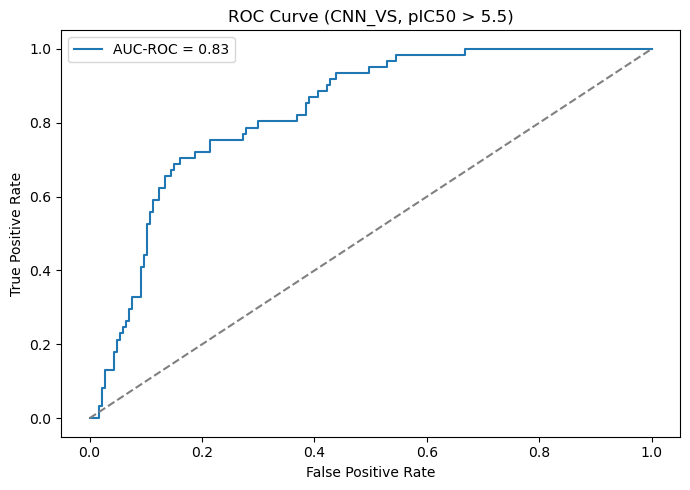

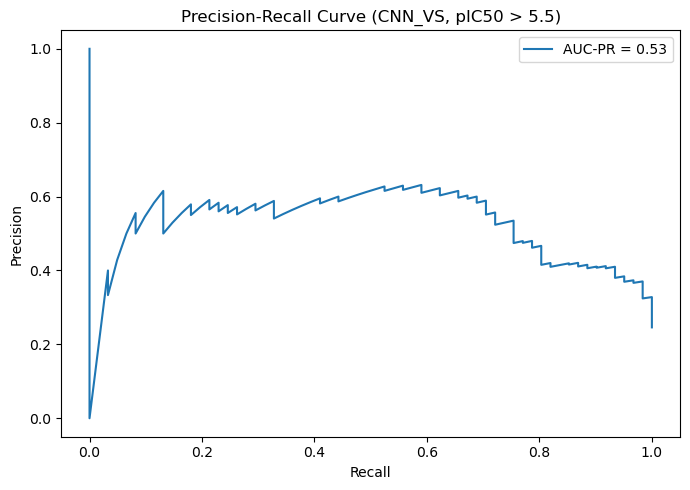

In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# Use pIC50 > 6 as "active" (positive class), else "inactive"
y_true = (combined_df['pIC50'] > 6).astype(int) # 5.5 is around 3 uM
y_score = combined_df['CNN_VS']

# Drop any rows with NaNs in either array
mask = (~np.isnan(y_true)) & (~np.isnan(y_score))
y_true = y_true[mask]
y_score = y_score[mask]

print(y_true.value_counts())

# Compute AUC-ROC and AUC-PR for CNN_VS
auc_roc = roc_auc_score(y_true, y_score)
auc_pr = average_precision_score(y_true, y_score)

print(f"AUC-ROC (CNN_VS): {auc_roc:.3f}")
print(f"AUC-PR (CNN_VS): {auc_pr:.3f}")

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC-ROC = {auc_roc:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN_VS, pIC50 > 5.5)")
plt.legend()
plt.tight_layout()
plt.show()

# PR curve
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (CNN_VS, pIC50 > 5.5)")
plt.legend()
plt.tight_layout()
plt.show()